# Import libraries

In [288]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Check data-frame

In [289]:
df = pd.read_csv('KaggleV2-May-2016.csv')
display(df.head())
df.info()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 11.8 MB


# 2. Feature Engineering
1. Change column's name
2. Convert date to pandas form

In [290]:
# Changing column's name 
df = df.rename( columns={
    'PatientId' : 'patient_id',
    'AppointmentID': 'appoitment_id',
    'Gender': 'gender',
    'No-show': 'no_show',
    'Handcap': 'handicap',
    'Age': 'age',
    'Hipertension': 'Hypertension'
    })

# Converting date
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay']).dt.normalize()
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay']).dt.normalize()
df['awaiting_days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days


display(df)

,patient_id,appoitment_id,gender,ScheduledDay,AppointmentDay,age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,handicap,SMS_received,no_show,awaiting_days
0,2.987250e+13,5642903,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0
1,5.589978e+14,5642503,M,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0
2,4.262962e+12,5642549,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,0
3,8.679512e+11,5642828,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,0
4,8.841186e+12,5642494,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,F,2016-05-03 00:00:00+00:00,2016-06-07 00:00:00+00:00,56,MARIA ORTIZ,0,0,0,0,0,1,No,35
110523,3.596266e+12,5650093,F,2016-05-03 00:00:00+00:00,2016-06-07 00:00:00+00:00,51,MARIA ORTIZ,0,0,0,0,0,1,No,35
110524,1.557663e+13,5630692,F,2016-04-27 00:00:00+00:00,2016-06-07 00:00:00+00:00,21,MARIA ORTIZ,0,0,0,0,0,1,No,41
110525,9.213493e+13,5630323,F,2016-04-27 00:00:00+00:00,2016-06-07 00:00:00+00:00,38,MARIA ORTIZ,0,0,0,0,0,1,No,41


# 3. Checking validation of data

In [291]:
df.describe()

,patient_id,appoitment_id,age,Scholarship,Hypertension,Diabetes,Alcoholism,handicap,SMS_received,awaiting_days
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026,10.183702
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873,15.254996
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,15.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,179.000000


Lets look at our columns and understand, something **wrong**.
1. Column 'Age' = minimum -1 and maximum 115
2. Column 'awaiting_days' = minimum -6

About handicap - there are 4 stages of handicap, so this is the reason, why maximum in cloumn 'handicap' is 4

Lets clean it.

In [292]:
# Make situation with hadicap clear
df['handicap'].value_counts()

handicap
0    108286
1      2042
2       183
3        13
4         3
Name: count, dtype: int64

In [293]:
df = df[(df['age'] > 0)]
df = df[df['awaiting_days'] >= 0]

df.describe()

,patient_id,appoitment_id,age,Scholarship,Hypertension,Diabetes,Alcoholism,handicap,SMS_received,awaiting_days
count,1.069820e+05,1.069820e+05,106982.000000,106982.000000,106982.000000,106982.000000,106982.000000,106982.000000,106982.000000,106982.000000
mean,1.472785e+14,5.675434e+06,38.316315,0.101036,0.203782,0.074246,0.031407,0.022957,0.323279,10.167290
std,2.558181e+14,7.133426e+04,22.466023,0.301377,0.402811,0.262172,0.174416,0.164064,0.467730,15.263631
min,3.921784e+04,5.030230e+06,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.173345e+12,5.640488e+06,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.172598e+13,5.680744e+06,38.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
75%,9.433627e+13,5.725639e+06,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,14.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,179.000000


In [294]:
df['no_show'].value_counts()


no_show
No     85307
Yes    21675
Name: count, dtype: int64

We need to change string on integers, because it will give us more information

In [295]:
df['no_show_int'] = df['no_show'].map({'Yes': 0, 'No': 1})

df['no_show_int'].value_counts()

no_show_int
1    85307
0    21675
Name: count, dtype: int64

# 4. Is it true that the longer a patient waits for an appointment, the more often they forget to come?

We need to understand whether delays in visits affect attendance.

In [296]:
wait_analysis = df.groupby('awaiting_days').agg({'patient_id': 'count', 'no_show_int': 'mean'})

wait_analysis.head(10)

,patient_id,no_show_int
awaiting_days,,
0,37154,0.953141
1,5028,0.786197
2,6636,0.761302
3,2639,0.763926
4,5212,0.768035
5,3196,0.735294
6,3950,0.753165
7,4785,0.734378
8,2248,0.710854


In [297]:
wait_analysis.tail(10)

,patient_id,no_show_int
awaiting_days,,
133,11,0.636364
139,1,0.000000
142,8,0.625000
146,1,0.000000
151,1,0.000000
155,10,0.400000
162,11,0.818182
169,8,0.875000
176,16,0.625000


We can't draw conclusions from the numbers; we need to create a graph for clarity.
But let's also clarify one thing: we'll exclude data with fewer than 50 patients.

In [298]:
clean_wait_analysis = wait_analysis[wait_analysis['patient_id'] > 50].reset_index()

display(clean_wait_analysis)

,awaiting_days,patient_id,no_show_int
0,0,37154,0.953141
1,1,5028,0.786197
2,2,6636,0.761302
3,3,2639,0.763926
4,4,5212,0.768035
...,...,...,...
71,75,72,0.694444
72,76,65,0.692308
73,84,54,0.777778
74,90,57,0.771930


<Axes: xlabel='awaiting_days', ylabel='no_show_int'>

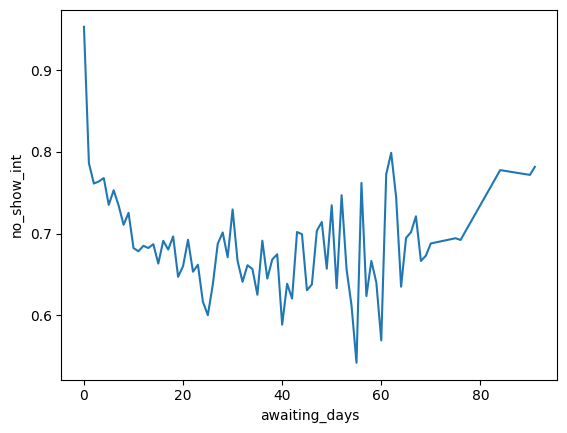

In [299]:
# lets draw

sns.lineplot(data=clean_wait_analysis, x='awaiting_days', y='no_show_int')

In [300]:
granicy = [-1, 0, 7, 30, 999]

name = ['same_day', 'week', 'month', 'more_mounth']

df['wait_period'] = pd.cut(df['awaiting_days'], bins=granicy, labels=name)

display(df.head(10))

,patient_id,appoitment_id,gender,ScheduledDay,AppointmentDay,age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,handicap,SMS_received,no_show,awaiting_days,no_show_int,wait_period
0,2.987250e+13,5642903,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0,1,same_day
1,5.589978e+14,5642503,M,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0,1,same_day
2,4.262962e+12,5642549,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,0,1,same_day
3,8.679512e+11,5642828,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,0,1,same_day
4,8.841186e+12,5642494,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No,0,1,same_day
5,9.598513e+13,5626772,F,2016-04-27 00:00:00+00:00,2016-04-29 00:00:00+00:00,76,REPÚBLICA,0,1,0,0,0,0,No,2,1,week
6,7.336882e+14,5630279,F,2016-04-27 00:00:00+00:00,2016-04-29 00:00:00+00:00,23,GOIABEIRAS,0,0,0,0,0,0,Yes,2,0,week
7,3.449833e+12,5630575,F,2016-04-27 00:00:00+00:00,2016-04-29 00:00:00+00:00,39,GOIABEIRAS,0,0,0,0,0,0,Yes,2,0,week
8,5.639473e+13,5638447,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,21,ANDORINHAS,0,0,0,0,0,0,No,0,1,same_day
9,7.812456e+13,5629123,F,2016-04-27 00:00:00+00:00,2016-04-29 00:00:00+00:00,19,CONQUISTA,0,0,0,0,0,0,No,2,1,week


In [301]:
df['wait_period'].value_counts()

wait_period
same_day       37154
week           31446
month          28386
more_mounth     9996
Name: count, dtype: int64

In [302]:
df_wait_period = df.groupby('wait_period').agg({'no_show_int': 'mean'})

display(df_wait_period)

,no_show_int
wait_period,
same_day,0.953141
week,0.758856
month,0.681674
more_mounth,0.668367


<Axes: xlabel='wait_period', ylabel='no_show_int'>

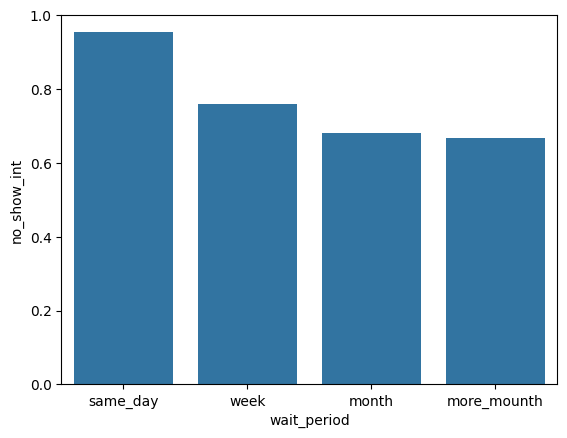

In [303]:
sns.barplot(data=df_wait_period, x='wait_period', y='no_show_int')

We can understand that patients who come every day are much more profitable than those who wait longer.

# 5. Does sending SMS increase patient retention rates?

In [304]:
df['SMS_received'].value_counts()

SMS_received
0    72397
1    34585
Name: count, dtype: int64

In [305]:
sms_analysis = df.groupby(['wait_period', 'SMS_received']).agg({'patient_id': 'count', 'no_show_int': 'mean'}).reset_index()

display(sms_analysis)


,wait_period,SMS_received,patient_id,no_show_int
0,same_day,0,37154,0.953141
1,week,0,20073,0.756887
2,week,1,11373,0.762332
3,month,0,11347,0.642989
4,month,1,17039,0.707436
5,more_mounth,0,3823,0.624640
6,more_mounth,1,6173,0.695448


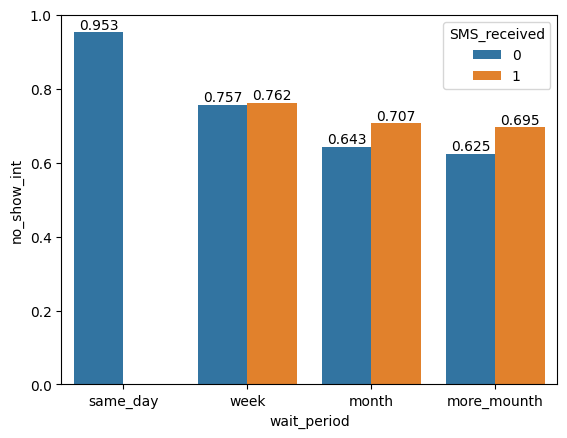

In [306]:
ax = sns.barplot(data=sms_analysis, x='wait_period', y='no_show_int', hue='SMS_received')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=0)

plt.ylim(0, 1)
plt.show()

From this graph, we can see that sending SMS is indeed a great way to attract patients. Almost 7 percent more patients come after receiving SMS.

# 6. Who's more likely to miss appointments—young people or older people? Do diagnoses (diabetes, hypertension) play a role?

Lets start with categories of people(young and old)

In [307]:
df.groupby(['age', 'wait_period'])['no_show_int'].sum()

age  wait_period
1    same_day       1167
     week            272
     month           302
     more_mounth     117
2    same_day        872
                    ... 
102  week              1
115  same_day          1
     week              0
     month             1
     more_mounth       0
Name: no_show_int, Length: 399, dtype: int64

In [308]:
granicy = [-1, 18, 35, 60, 999]

name = ['child', 'young', 'old', 'super_old']

df['category_age'] = pd.cut(df['age'], bins=granicy, labels=name)

display(df.head())

,patient_id,appoitment_id,gender,ScheduledDay,AppointmentDay,age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,handicap,SMS_received,no_show,awaiting_days,no_show_int,wait_period,category_age
0,2.987250e+13,5642903,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0,1,same_day,super_old
1,5.589978e+14,5642503,M,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0,1,same_day,old
2,4.262962e+12,5642549,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,0,1,same_day,super_old
3,8.679512e+11,5642828,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,0,1,same_day,child
4,8.841186e+12,5642494,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No,0,1,same_day,old


In [325]:
category = df.groupby(['category_age']).agg({'no_show_int': 'mean'})

display(category)

,no_show_int
category_age,
child,0.774658
young,0.761715
old,0.809004
super_old,0.847933


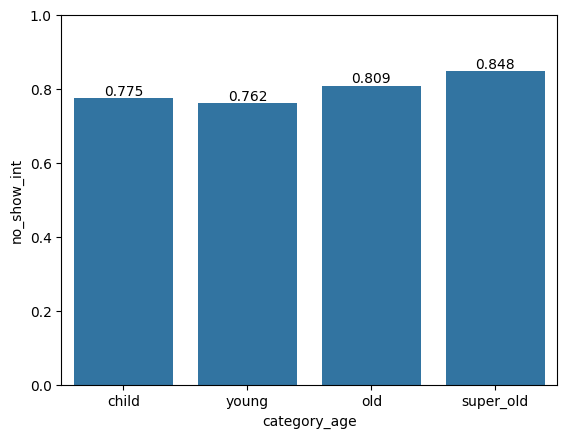

In [326]:
ax = sns.barplot(data=category, x='category_age', y='no_show_int')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=0)

plt.ylim(0, 1)
plt.show()

From this graph we can see that people aged 18-35 are the least likely to visit a doctor.

Let's continue with people who are sick with something.

In [312]:
df['has_disies'] = df['Hypertension'] + df['Diabetes'] + df['Alcoholism']

display(df.head())

,patient_id,appoitment_id,gender,ScheduledDay,AppointmentDay,age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,handicap,SMS_received,no_show,awaiting_days,no_show_int,wait_period,category_age,has_disies
0,2.987250e+13,5642903,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0,1,same_day,super_old,1
1,5.589978e+14,5642503,M,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0,1,same_day,old,0
2,4.262962e+12,5642549,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,0,1,same_day,super_old,0
3,8.679512e+11,5642828,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,0,1,same_day,child,0
4,8.841186e+12,5642494,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No,0,1,same_day,old,2


In [318]:
disies = df.groupby(['has_disies']).agg({'no_show_int': 'mean'})

display(disies)

,no_show_int
has_disies,
0,0.789720
1,0.822034
2,0.822963
3,0.820312


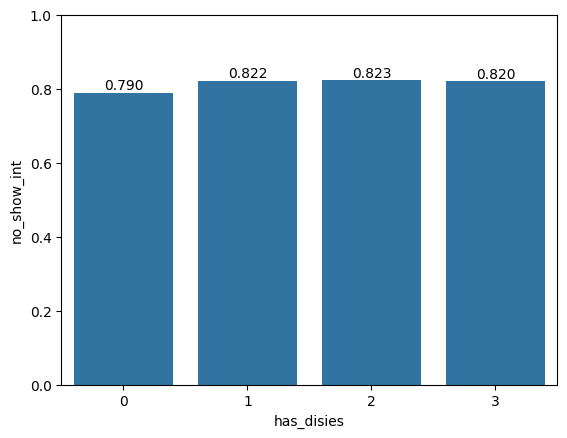

In [319]:
ax = sns.barplot(data=disies, x='has_disies', y='no_show_int')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=0)

plt.ylim(0, 1)
plt.show()

We can see from the graph that people with health problems come more than healthy people.

In conclusion, I'd like to draw a few conclusions.
1. People aged 18-35 miss doctor's appointments more often than children or the elderly. This may be due to schedule issues or other commitments.
2. People with illnesses are more likely to keep appointments than healthy people.